# The J1-J2 model

The [J1-J2 model](https://en.wikipedia.org/wiki/J1_J2_model) contains both nearest-neighbor and next-to-nearest-neighbor interactions.
$$H = J_1 \sum_{\langle i, j \rangle} \vec{\sigma}_i \cdot \vec{\sigma}_j + J_2 \sum_{\langle \langle i, j \rangle \rangle} \vec{\sigma}_i \cdot \vec{\sigma}_j$$

In [27]:
from typing import Dict, List
from dataclasses import dataclass
from copy import deepcopy
import h5py
from math import sqrt
import numpy as np
import scipy as sp
import scipy.linalg as la
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
import networkx as nx
import cirq
import openfermion as of
import qiskit
from quimb.tensor import DMRG
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, total_number_qubit_operator, get_evolved_states,
    fill_subspace_matrices_mps, mps_to_vector, exact_evolved_states,
    fill_subspace_matrices_vectors
)

In [28]:
def j1j2_hamiltonian(graph: nx.Graph, j1: float, j2: float) -> cirq.PauliSum:
    """Get the J1-J2 Hamiltonian."""

    qs = cirq.LineQubit.range(len(graph.nodes))
    ham = cirq.PauliSum()
    for i in graph.nodes:
        neighbors = graph.neighbors(i)
        for j in neighbors:
            sigma_dot_sigma = 1.0 * cirq.X.on(qs[i]) * cirq.X.on(qs[j]) \
                + 1.0 * cirq.Y.on(qs[i]) * cirq.Y.on(qs[j]) \
                + 1.0 * cirq.Z.on(qs[i]) * cirq.Z.on(qs[j])
            ham += 0.5 * j1 * sigma_dot_sigma
            j_neighbors = graph.neighbors(j)
            for jn in j_neighbors:
                if jn != i:
                    sigma_dot_sigma = 1.0 * cirq.X.on(qs[i]) * cirq.X.on(qs[jn]) \
                        + 1.0 * cirq.Y.on(qs[i]) * cirq.Y.on(qs[jn]) \
                        + 1.0 * cirq.Z.on(qs[i]) * cirq.Z.on(qs[jn])
                    ham += 0.5 * j2 * sigma_dot_sigma
    return ham

In [34]:
@dataclass
class J1J2Result:
    j1: float
    j2: float
    exact_energy: float
    chi_dmrg: List[int]
    chi_tdvp: List[int]
    dmrg_energies: List[float]
    krylov_energies: np.ndarray

    def plot(self, energy_ax: Axes, error_ax: Axes):
        krylov_errs = np.abs(self.krylov_energies - self.exact_energy)

        markers = [".", "o", ">", "P"]
        colors = ["k", "b", "g", "r"]
        for i, chi in enumerate(self.chi_dmrg):
            energy_ax.hlines(self.dmrg_energies[i], 0., self.krylov_energies.shape[1], colors=colors[i], label=f"DMRG chi={chi}")
        energy_ax.hlines(self.exact_energy, 0., self.krylov_energies.shape[1], colors="y", label="ED")
        for i, chi in enumerate(self.chi_tdvp):
            energy_ax.plot(self.krylov_energies[i, :], marker=markers[i], label=f"TEBD chi={chi}")
            error_ax.plot(krylov_errs[i, :], marker=markers[i], label=f"TEBD chi={chi}")
        energy_ax.legend()
        energy_ax.set_ylabel("Energy")
        energy_ax.set_title(f"J2/J1={self.j2/self.j1}")
        error_ax.set_ylabel("Aboslute error")
        error_ax.set_xlabel("d")
        error_ax.set_yscale("log")


def solve_case(
    bond_dims: List[int], j1: float, j2: float, mpo_bond: int=100,
    l: int = 6, d: int = 20, tau: float = 0.1, steps: int=10, eps: float = 1e-10,
    twod: bool=False
) -> J1J2Result:
    """Solve a case."""

    if twod:
        grid_graph = nx.grid_graph(dim=(l, l))
    else:
        grid_graph = nx.grid_graph(dim=(l, 1))
    grid_graph = nx.convert_node_labels_to_integers(grid_graph)
    hamiltonian = j1j2_hamiltonian(grid_graph, j1, j2)
    ham_mpo = pauli_sum_to_mpo(hamiltonian, hamiltonian.qubits, mpo_bond)

    # Exact diagonalization.
    ham_matrix = hamiltonian.matrix()
    eigvals, eigvecs = la.eigh(ham_matrix)
    ground_energy = np.min(eigvals)
    print(f"Exact energy: {ground_energy}")

    # Solve with DMRG.
    dmrg_bond_dims = deepcopy(bond_dims)
    dmrg_energies = []
    dmrg_states = []
    for chi_dmrg in dmrg_bond_dims:
        print(f"chi = {chi_dmrg}")
        dmrg = DMRG(ham_mpo, chi_dmrg)
        converged = dmrg.solve()
        if not converged:
            print("DMRG did not converge!")
        ground_energy = dmrg.energy.real
        print(f"Got energy {ground_energy}")
        ground_state = dmrg.state
        dmrg_states.append(ground_state.copy())
        dmrg_energies.append(ground_energy)

    # Solve with Krylov.
    ev_circuit = trotter_circuit_from_psum(hamiltonian, tau, steps)
    ev_circuit_transpiled = qiskit.transpile(ev_circuit)
    krylov_bond_dims = deepcopy(dmrg_bond_dims)
    krylov_energies = np.zeros((len(bond_dims), d-1), dtype=float)
    ref_state = dmrg_states[0].copy()
    for i, chi in enumerate(krylov_bond_dims):
        print(f"chi = {chi}")
        states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi, None)
        h, s = fill_subspace_matrices_mps(states, ham_mpo)
        energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
        krylov_energies[i, :] = energies
    
    return J1J2Result(j1, j2, ground_energy, dmrg_bond_dims, krylov_bond_dims, dmrg_energies, krylov_energies)

In [35]:
bond_dims = [2, 4, 6, 8]
j1 = 1.0
j2_vals = [0., 1., 2.]
results = []
for j2 in j2_vals:
    print(f"j2 = {j2}")
    result = solve_case(bond_dims, j1, j2, l=3, twod=True)
    results.append(result)

j2 = 0.0
Exact energy: -18.997309034211487
chi = 2
DMRG did not converge!
Got energy -15.77800750208775
chi = 4
Got energy -17.725547893030388
chi = 6
Got energy -18.46312927235926
chi = 8
Got energy -18.913710892212116
chi = 2
chi = 4
chi = 6
chi = 8
j2 = 1.0
Exact energy: -26.340855685161465
chi = 2
DMRG did not converge!
Got energy -18.594321520407224
chi = 4
Got energy -23.313002028926164
chi = 6
Got energy -24.804352262006134
chi = 8
Got energy -25.115364182648257
chi = 2
chi = 4
chi = 6
chi = 8
j2 = 2.0
Exact energy: -52.15508918881216
chi = 2
DMRG did not converge!
Got energy -32.45354532996129
chi = 4
DMRG did not converge!
Got energy -45.346248281430064
chi = 6
DMRG did not converge!
Got energy -49.01782288116386
chi = 8
DMRG did not converge!
Got energy -49.685953609480855
chi = 2
chi = 4
chi = 6
chi = 8


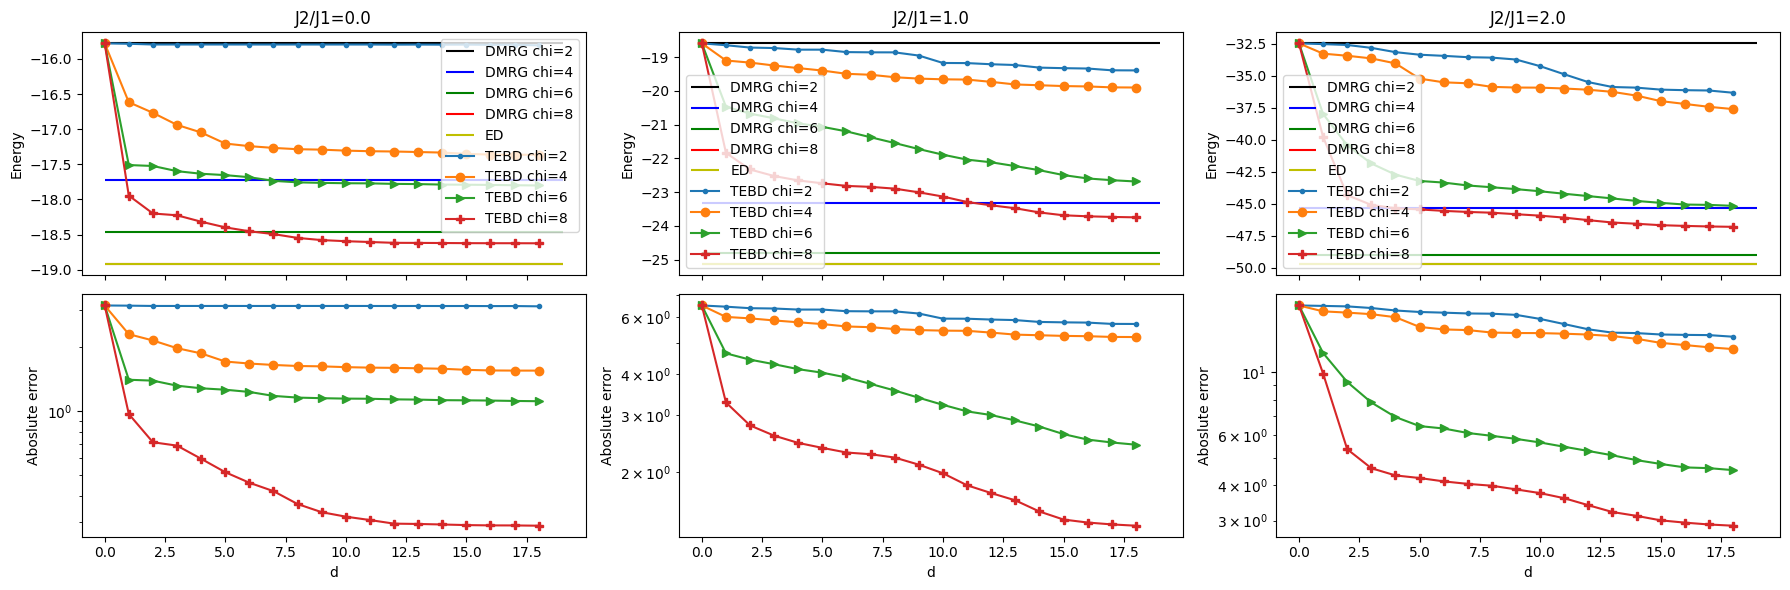

In [36]:
fig, ax = plt.subplots(2, len(results), sharex=True, figsize=(18, 6))
for i, result in enumerate(results):
    result.plot(ax[0, i], ax[1, i])
fig.tight_layout()
plt.savefig("data/j1j2.pdf")